# Projet 1 — Prédiction du succès d'une campagne marketing bancaire

**Membres du groupe :**
- ABEGUEDIA Rosane Yvanne Boyama  
- BARRY Mamoudou  
- DAMIENS Elodie  
- GUILLEMINOT Paul  
- TOUAMI Zakaria

**Groupe :** D  
**Jeu de données :** `bank-full.csv`  
**Objectif :** comprendre les facteurs associés à la souscription d'un produit d'épargne et construire un modèle capable d'aider la banque à mieux cibler ses appels.

## 1. Problématique et logique d'analyse

La banque mène des campagnes téléphoniques pour proposer un dépôt à terme à ses clients.  
La variable cible `y` indique si le client a finalement **souscrit (`yes`) ou non (`no`)**.

Dans ce notebook, on suit une démarche complète :

1. **Comprendre le dataset** et vérifier sa qualité.
2. **Explorer les données** pour identifier les profils les plus réceptifs.
3. **Tester statistiquement** certaines relations observées.
4. **Construire plusieurs modèles** de classification.
5. **Comparer les performances** et discuter les limites.
6. **Ajuster le seuil de décision** selon un objectif métier.

L'idée n'est pas seulement d'obtenir un bon score, mais de produire une analyse **claire, justifiée et interprétable**.

In [41]:
# ============================================================
# Imports
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from scipy.stats import chi2_contingency, mannwhitneyu

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# XGBoost est utilisé seulement s'il est disponible
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

# Style graphique
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 2. Chargement des données

On commence par charger le fichier CSV puis par vérifier sa structure générale.  
Cette étape est indispensable car elle permet de répondre aux premières questions :

- combien y a-t-il d'observations ?
- combien y a-t-il de variables ?
- quels sont les types de colonnes ?
- la cible est-elle équilibrée ou non ?

In [ ]:
data = pd.read_csv("bank-full.csv", sep=";")
print(f"Dimensions du dataset : {data.shape[0]:,} lignes × {data.shape[1]} colonnes")

display(data.head())

Dimensions du dataset : 45,211 lignes × 17 colonnes


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### Lecture initiale

Le dataset contient des variables :

- **sociodémographiques** : `age`, `job`, `marital`, `education`
- **financières** : `balance`, `default`, `housing`, `loan`
- **liées à la campagne** : `contact`, `day`, `month`, `duration`, `campaign`
- **liées à l'historique marketing** : `pdays`, `previous`, `poutcome`
- **cible** : `y`

On est donc bien dans un problème de **classification binaire**.

## 3. Data canvas — compréhension des variables

Avant de modéliser, il faut expliciter le rôle des variables.  
Cette étape aide à distinguer :

- les variables probablement **prédictives** ;
- les variables possiblement **redondantes** ;
- les variables qui peuvent créer un **biais de fuite d'information**.

In [ ]:
description = pd.DataFrame({
    "variable": data.columns,
    "type": data.dtypes.astype(str).values,
    "nb_modalites_ou_infos": [data[col].nunique() for col in data.columns],
    "exemple": [data[col].dropna().iloc[0] if data[col].notna().any() else np.nan for col in data.columns]
})

display(description)

,variable,type,nb_modalites_ou_infos,exemple
0,age,int64,77,58
1,job,object,12,management
2,marital,object,3,married
3,education,object,4,tertiary
4,default,object,2,no
5,balance,int64,7168,2143
6,housing,object,2,yes
7,loan,object,2,no
8,contact,object,3,unknown
9,day,int64,31,5


### Hypothèses métier formulées avant l'EDA

Avant même les graphiques, on peut déjà poser quelques hypothèses raisonnables :

- un client déjà réceptif par le passé (`poutcome = success`) devrait avoir une probabilité de souscription plus élevée ;
- un grand nombre de relances (`campaign`) peut traduire une difficulté à convaincre ;
- certaines professions ou niveaux d'études peuvent être associés à une meilleure réceptivité ;
- `duration` risque d'être **très prédictive**, mais cette variable est problématique d'un point de vue métier, car la durée n'est connue **qu'après l'appel**.

## 4. Analyse de la cible

Il faut toujours commencer par regarder la variable cible.  
Pourquoi ? Parce qu'un déséquilibre entre classes influence :

- le choix des métriques ;
- le choix éventuel de `class_weight`;
- l'interprétation des scores.

,y,effectif,proportion
0,no,39922,0.883
1,yes,5289,0.117


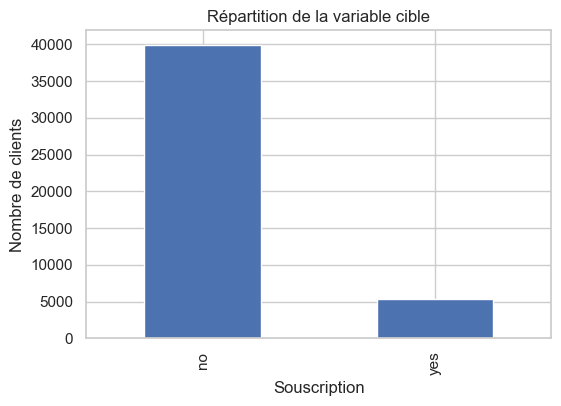

In [45]:
target_dist = (
    data["y"]
    .value_counts()
    .rename_axis("y")
    .reset_index(name="effectif")
)
target_dist["proportion"] = target_dist["effectif"] / len(data)

display(target_dist)

plt.figure(figsize=(6, 4))
data["y"].value_counts().sort_index().plot(kind="bar")
plt.title("Répartition de la variable cible")
plt.xlabel("Souscription")
plt.ylabel("Nombre de clients")
plt.show()

### Interprétation

La classe positive (`yes`) est nettement minoritaire.  
Cela signifie qu'un modèle qui prédirait presque toujours `no` pourrait afficher une accuracy correcte tout en étant peu utile en pratique.

**Conséquence méthodologique :** on ne se limitera pas à l'accuracy.  
On regardera aussi :

- la **précision** ;
- le **rappel** ;
- le **F1-score** ;
- la **ROC-AUC**.

## 5. Diagnostic de qualité des données

Avant l'EDA, on vérifie les problèmes les plus fréquents :

- valeurs manquantes ;
- doublons ;
- modalités ambiguës comme `unknown` ;
- valeurs atypiques ou extrêmes.

In [46]:
quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing_values": data.isna().sum(),
    "missing_rate_%": (data.isna().mean() * 100).round(2),
    "n_unique": data.nunique()
})
display(quality)
print(f"Doublons exacts : {data.duplicated().sum():,}")

,dtype,missing_values,missing_rate_%,n_unique
age,int64,0,0.000,77
job,object,0,0.000,12
marital,object,0,0.000,3
education,object,0,0.000,4
default,object,0,0.000,2
balance,int64,0,0.000,7168
housing,object,0,0.000,2
loan,object,0,0.000,2
contact,object,0,0.000,3
day,int64,0,0.000,31


Doublons exacts : 0


### Premier constat

Il n'y a pas de valeurs manquantes explicites au sens Pandas, mais cela ne veut pas dire qu'il n'y a **aucune information absente**.

Dans ce dataset, certaines colonnes catégorielles utilisent la modalité **`unknown`** pour coder une information inconnue.  
Il faut donc la traiter comme une **pseudo-valeur manquante**.

## 6. Étude des modalités `unknown`

Cette étape est importante pour deux raisons :

1. sur le plan analytique, une forte présence de `unknown` peut réduire l'interprétabilité ;
2. sur le plan du machine learning, on doit décider si cette modalité est conservée telle quelle ou transformée en valeur manquante imputée.

In [47]:
object_cols = data.select_dtypes(include="object").columns.tolist()

unknown_rows = []
for col in object_cols:
    unknown_count = (data[col] == "unknown").sum()
    unknown_rows.append({
        "variable": col,
        "unknown_count": int(unknown_count),
        "unknown_rate_%": round(100 * unknown_count / len(data), 2)
    })

unknown_df = pd.DataFrame(unknown_rows).sort_values("unknown_rate_%", ascending=False)
display(unknown_df)

,variable,unknown_count,unknown_rate_%
8,poutcome,36959,81.750
6,contact,13020,28.800
2,education,1857,4.110
0,job,288,0.640
1,marital,0,0.000
3,default,0,0.000
5,loan,0,0.000
4,housing,0,0.000
7,month,0,0.000
9,y,0,0.000


In [48]:
unknown_effect_rows = []

for col in object_cols:
    if (data[col] == "unknown").sum() > 0:
        tmp = (
            data.assign(target_num=(data["y"] == "yes").astype(int))
            .groupby(col)["target_num"]
            .mean()
            .reset_index()
            .rename(columns={"target_num": "subscription_rate"})
        )
        tmp["variable"] = col
        unknown_effect_rows.append(tmp)

unknown_effect = pd.concat(unknown_effect_rows, ignore_index=True)
display(unknown_effect[unknown_effect.iloc[:, 0] == "unknown"].sort_values("subscription_rate"))

,job,subscription_rate,variable,education,contact,poutcome
11,unknown,0.118,job,NaN,NaN,NaN


### Interprétation

Les modalités `unknown` ne sont pas neutres : elles peuvent être associées à un comportement de souscription particulier.  
On ne doit donc pas les supprimer brutalement sans réflexion.

Dans la partie modélisation, on fera un choix intermédiaire :

- remplacer `unknown` par une valeur manquante ;
- imputer ensuite automatiquement via le pipeline.

Cela permet d'avoir une logique de traitement homogène.

## 7. Analyse des variables numériques et des valeurs extrêmes

Les valeurs extrêmes peuvent fausser :

- la lecture des distributions ;
- les moyennes ;
- certains modèles, en particulier la régression logistique.

On les observe donc avant de décider d'un traitement.

In [49]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
display(data[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,"45,211.000",40.936,10.619,18.000,33.000,39.000,48.000,95.000
balance,"45,211.000","1,362.272","3,044.766","-8,019.000",72.000,448.000,"1,428.000","102,127.000"
day,"45,211.000",15.806,8.322,1.000,8.000,16.000,21.000,31.000
duration,"45,211.000",258.163,257.528,0.000,103.000,180.000,319.000,"4,918.000"
campaign,"45,211.000",2.764,3.098,1.000,1.000,2.000,3.000,63.000
pdays,"45,211.000",40.198,100.129,-1.000,-1.000,-1.000,-1.000,871.000
previous,"45,211.000",0.580,2.303,0.000,0.000,0.000,0.000,275.000


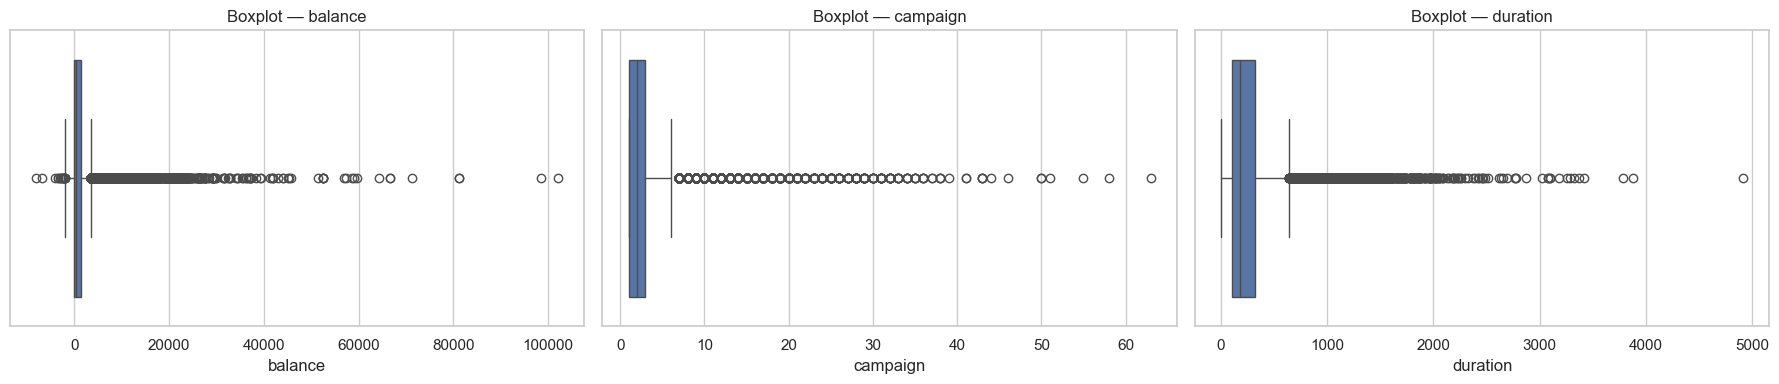

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.boxplot(data=data, x="balance", ax=axes[0])
axes[0].set_title("Boxplot — balance")

sns.boxplot(data=data, x="campaign", ax=axes[1])
axes[1].set_title("Boxplot — campaign")

sns.boxplot(data=data, x="duration", ax=axes[2])
axes[2].set_title("Boxplot — duration")

plt.tight_layout()
plt.show()

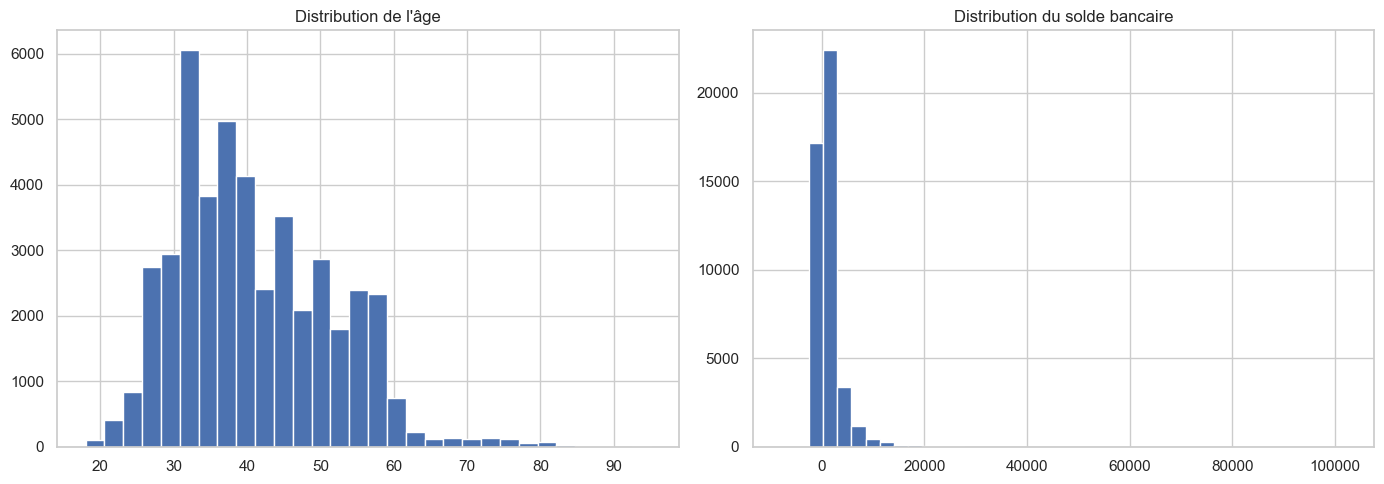

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data["age"], bins=30)
axes[0].set_title("Distribution de l'âge")

axes[1].hist(data["balance"], bins=40)
axes[1].set_title("Distribution du solde bancaire")

plt.tight_layout()
plt.show()

### Interprétation

On observe des distributions très asymétriques pour plusieurs variables, notamment `balance`, `campaign` et `duration`.  
Cela suggère la présence de **valeurs extrêmes** ou de longues queues de distribution.

Plutôt que de supprimer des lignes, on appliquera plus tard un **clipping basé sur l'IQR** dans le pipeline numérique.  
Cette stratégie est utile car elle limite l'influence des extrêmes tout en conservant toutes les observations.

## 8. Analyse univariée des variables catégorielles

L'objectif ici est de comprendre quelles modalités dominent dans l'échantillon.  
C'est utile pour repérer :

- les variables très déséquilibrées ;
- les modalités rares ;
- les premiers profils typiques des clients.

In [52]:
cat_cols = data.select_dtypes(include="object").columns.tolist()

cat_summary = pd.DataFrame({
    "n_modalites": [data[col].nunique() for col in cat_cols],
    "modalite_la_plus_frequente": [data[col].mode(dropna=False).iat[0] for col in cat_cols],
    "frequence_top": [data[col].value_counts(dropna=False).iat[0] for col in cat_cols]
}, index=cat_cols)

display(cat_summary)

,n_modalites,modalite_la_plus_frequente,frequence_top
job,12,blue-collar,9732
marital,3,married,27214
education,4,secondary,23202
default,2,no,44396
housing,2,yes,25130
loan,2,no,37967
contact,3,cellular,29285
month,12,may,13766
poutcome,4,unknown,36959
y,2,no,39922


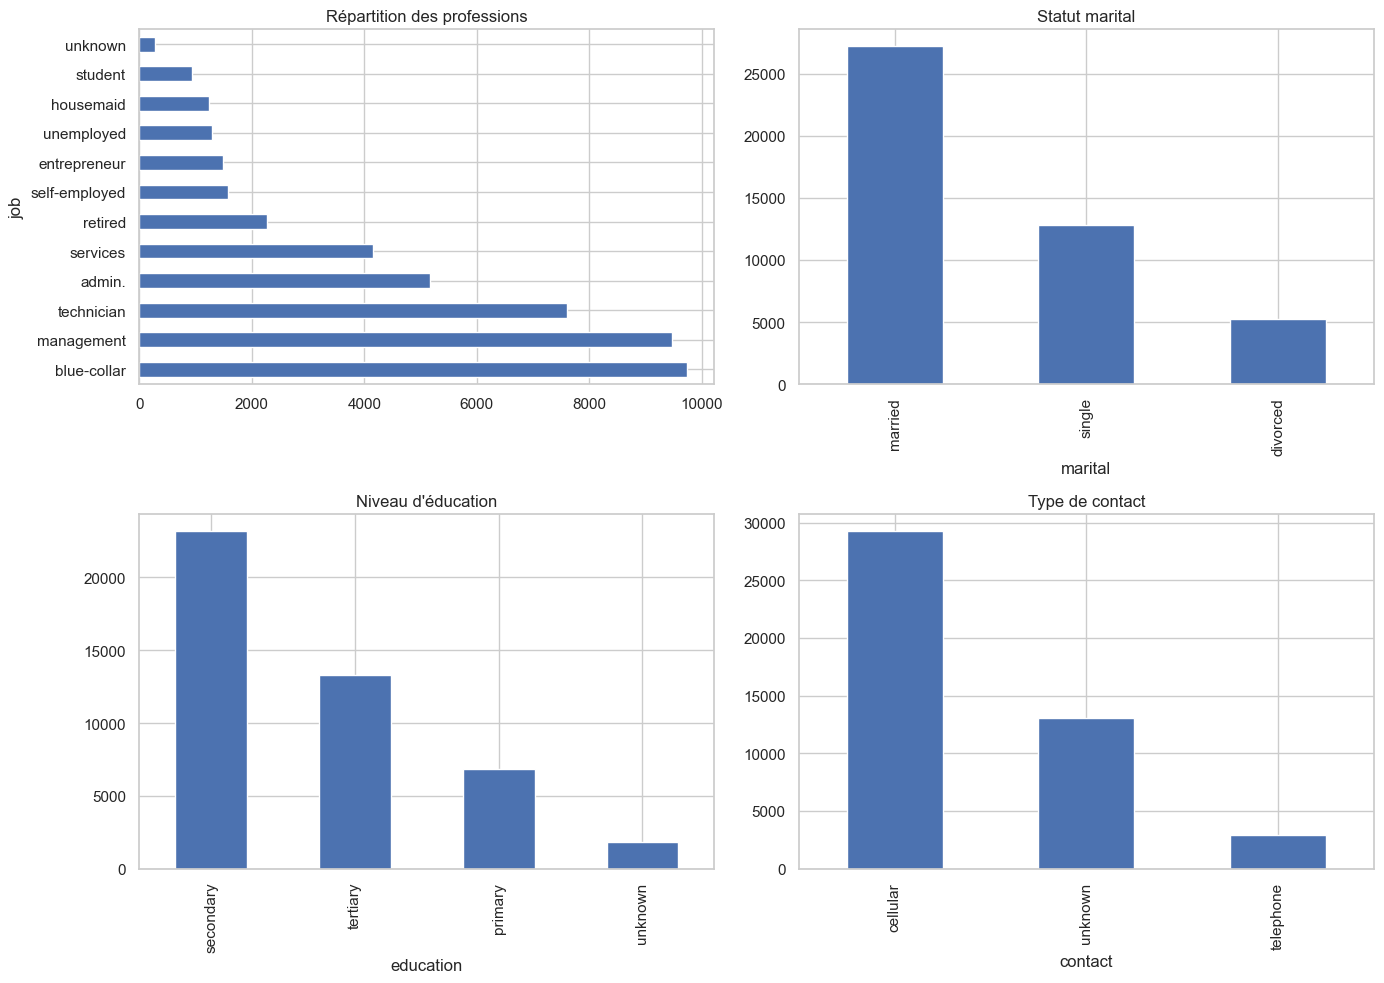

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

data["job"].value_counts().plot(kind="barh", ax=axes[0, 0])
axes[0, 0].set_title("Répartition des professions")

data["marital"].value_counts().plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Statut marital")

data["education"].value_counts().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Niveau d'éducation")

data["contact"].value_counts().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Type de contact")

plt.tight_layout()
plt.show()

### Interprétation

Cette lecture univariée renseigne sur la structure du portefeuille clients, mais elle ne suffit pas à expliquer la souscription.  
Pour cela, il faut maintenant croiser les variables avec `y`.

## 9. Création de variables dérivées utiles pour l'EDA

Créer quelques variables plus lisibles permet souvent d'améliorer l'interprétation :

- classes d'âge ;
- historique simplifié des contacts précédents ;
- indicateur global d'endettement.

Ces variables servent surtout à l'analyse exploratoire.  
Elles ne remplacent pas automatiquement les variables d'origine dans la modélisation.

In [54]:
eda_data = data.copy()

eda_data["age_group"] = pd.cut(
    eda_data["age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"],
    include_lowest=True
)

eda_data["previous_contact_group"] = pd.cut(
    eda_data["previous"],
    bins=[-1, 0, 4, np.inf],
    labels=["0 contact", "1 à 4 contacts", "5 contacts ou plus"]
)

eda_data["has_debt"] = ((eda_data["housing"] == "yes") | (eda_data["loan"] == "yes")).astype(int)

display(eda_data[["age_group", "previous_contact_group", "has_debt"]].head())

,age_group,previous_contact_group,has_debt
0,51-60,0 contact,1
1,41-50,0 contact,1
2,31-40,0 contact,1
3,41-50,0 contact,1
4,31-40,0 contact,0


## 10. Matrice d'association adaptée aux variables mixtes

Une matrice de corrélation classique n'est pas suffisante ici, car le dataset contient à la fois :

- des variables **numériques** ;
- des variables **catégorielles**.

On construit donc une matrice d'association mixte :

- **corrélation de Pearson** pour numérique / numérique ;
- **rapport de corrélation** pour catégoriel / numérique ;
- **V de Cramér** pour catégoriel / catégoriel.

Le but n'est pas de chercher une causalité, mais de repérer les variables les plus liées à la cible.

In [55]:
def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    if contingency.empty:
        return np.nan
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.to_numpy().sum()
    r, k = contingency.shape
    if n == 0 or min(r, k) <= 1:
        return np.nan
    return np.sqrt((chi2 / n) / min(r - 1, k - 1))


def correlation_ratio(categories, measurements):
    categories = pd.Series(categories)
    measurements = pd.Series(measurements)
    valid = ~(categories.isna() | measurements.isna())
    categories = categories[valid]
    measurements = measurements[valid]

    if categories.nunique() <= 1:
        return np.nan

    grand_mean = measurements.mean()
    denominator = ((measurements - grand_mean) ** 2).sum()
    if denominator == 0:
        return 0.0

    numerator = 0.0
    for cat in categories.unique():
        vals = measurements[categories == cat]
        numerator += len(vals) * (vals.mean() - grand_mean) ** 2

    return np.sqrt(numerator / denominator)


numeric_cols_eda = eda_data.select_dtypes(include=np.number).columns.tolist()
categorical_cols_eda = eda_data.select_dtypes(exclude=np.number).columns.tolist()

cols = eda_data.columns.tolist()
assoc_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for col1 in cols:
    for col2 in cols:
        if col1 == col2:
            assoc_matrix.loc[col1, col2] = 1.0
        elif col1 in numeric_cols_eda and col2 in numeric_cols_eda:
            assoc_matrix.loc[col1, col2] = eda_data[[col1, col2]].corr().iloc[0, 1]
        elif col1 in categorical_cols_eda and col2 in categorical_cols_eda:
            assoc_matrix.loc[col1, col2] = cramers_v(eda_data[col1], eda_data[col2])
        elif col1 in categorical_cols_eda and col2 in numeric_cols_eda:
            assoc_matrix.loc[col1, col2] = correlation_ratio(eda_data[col1], eda_data[col2])
        else:
            assoc_matrix.loc[col1, col2] = correlation_ratio(eda_data[col2], eda_data[col1])

assoc_with_target = assoc_matrix["y"].drop("y").sort_values(ascending=False)
display(assoc_with_target.to_frame("association_with_y").head(12))

,association_with_y
duration,0.395
poutcome,0.312
month,0.260
age_group,0.173
previous_contact_group,0.169
has_debt,0.159
contact,0.151
housing,0.139
job,0.136
pdays,0.104


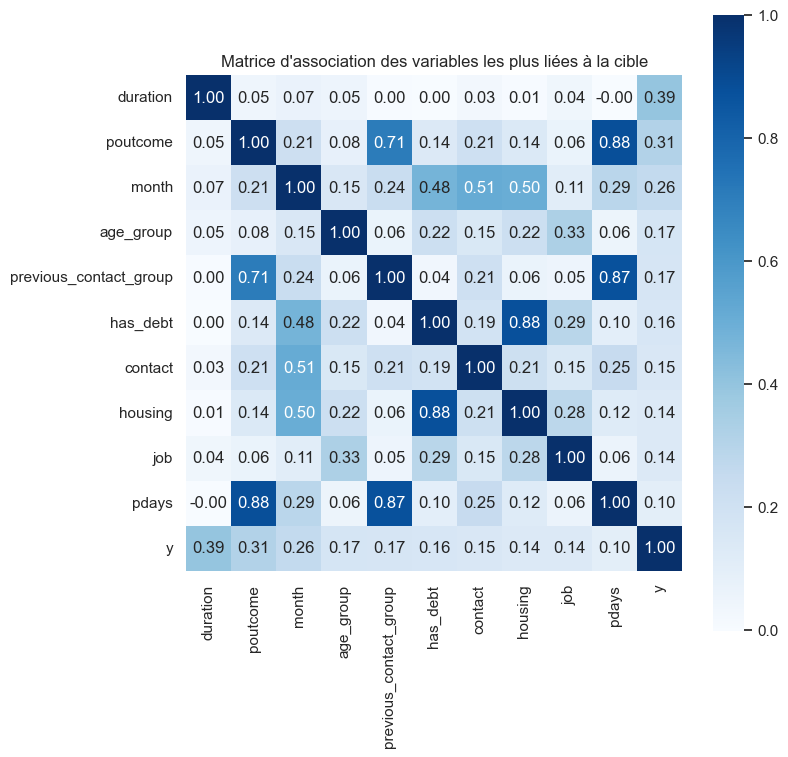

In [56]:
plt.figure(figsize=(8, 8))
sns.heatmap(assoc_matrix.loc[assoc_with_target.head(10).index.tolist() + ["y"],
                            assoc_with_target.head(10).index.tolist() + ["y"]],
            annot=True, fmt=".2f", cmap="Blues", square=True)
plt.title("Matrice d'association des variables les plus liées à la cible")
plt.show()

### Interprétation

Cette matrice permet d'identifier rapidement les variables les plus informatives vis-à-vis de `y`.  
Dans ce type de dataset, `duration`, `poutcome`, `previous` et certaines variables de contact ressortent souvent fortement.

**Attention toutefois :** une variable très liée à la cible n'est pas forcément acceptable en prédiction métier.  
C'est notamment le cas de `duration`, qui sera exclue du modèle final de ciblage.

## 11. Analyse bivariée ciblée

On passe maintenant à des graphiques plus directement interprétables.  
L'objectif est double :

- visualiser des différences de profil entre les clients qui souscrivent et ceux qui ne souscrivent pas ;
- préparer la discussion métier.

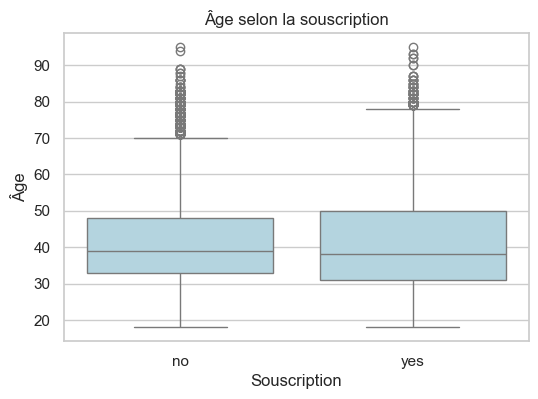

In [57]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=eda_data, x="y", y="age", color="lightblue")
plt.title("Âge selon la souscription")
plt.xlabel("Souscription")
plt.ylabel("Âge")
plt.show()

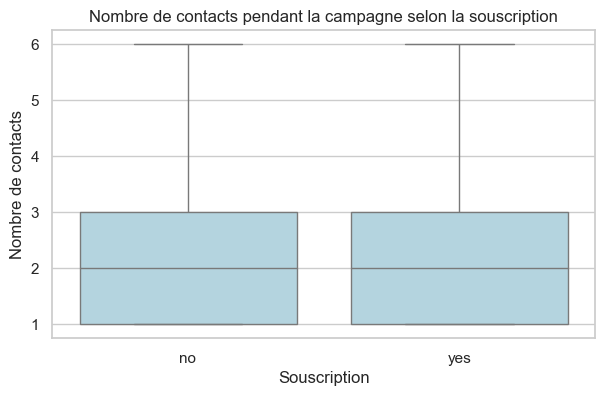

In [58]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=eda_data, x="y", y="campaign", showfliers=False, color="lightblue")
plt.title("Nombre de contacts pendant la campagne selon la souscription")
plt.xlabel("Souscription")
plt.ylabel("Nombre de contacts")
plt.show()

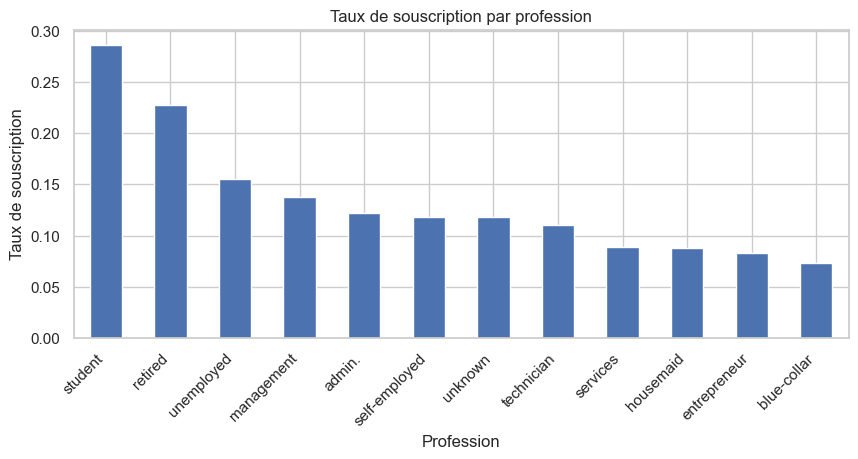

In [59]:
plt.figure(figsize=(10, 4))
order = eda_data.groupby("job")["y"].apply(lambda s: (s == "yes").mean()).sort_values(ascending=False).index

job_rate = eda_data.assign(subscribed=(eda_data["y"] == "yes").astype(int)).groupby("job")["subscribed"].mean().loc[order]
job_rate.plot(kind="bar")

plt.xticks(rotation=45, ha="right")
plt.title("Taux de souscription par profession")
plt.xlabel("Profession")
plt.ylabel("Taux de souscription")
plt.show()

,subscription_rate
poutcome,
success,0.647
other,0.167
failure,0.126
unknown,0.092


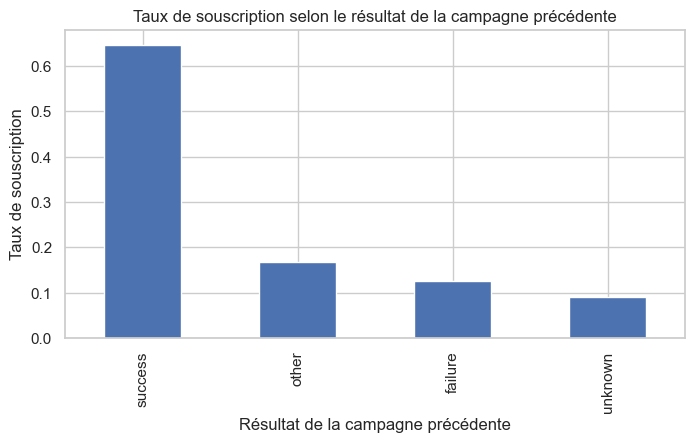

In [60]:
poutcome_rate = (
    eda_data.assign(subscribed=(eda_data["y"] == "yes").astype(int))
    .groupby("poutcome")["subscribed"]
    .mean()
    .sort_values(ascending=False)
    .to_frame("subscription_rate")
)
display(poutcome_rate)

plt.figure(figsize=(8, 4))
poutcome_rate["subscription_rate"].plot(kind="bar")
plt.title("Taux de souscription selon le résultat de la campagne précédente")
plt.xlabel("Résultat de la campagne précédente")
plt.ylabel("Taux de souscription")
plt.show()

C:\Users\Elodi\AppData\Local\Temp\ipykernel_21932\1488529361.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_data.groupby("previous_contact_group")["y"]


y,no,yes
previous_contact_group,,
0 contact,0.908,0.092
1 à 4 contacts,0.777,0.223
5 contacts ou plus,0.737,0.263


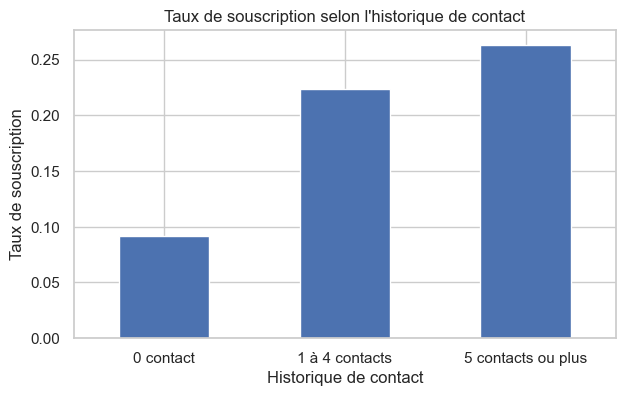

In [61]:
subscription_rate = (
    eda_data.groupby("previous_contact_group")["y"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

display(subscription_rate)

subscription_rate["yes"].plot(kind="bar", figsize=(7, 4))
plt.title("Taux de souscription selon l'historique de contact")
plt.xlabel("Historique de contact")
plt.ylabel("Taux de souscription")
plt.xticks(rotation=0)
plt.show()

y,no,yes
has_debt,,
0,0.818,0.182
1,0.923,0.077


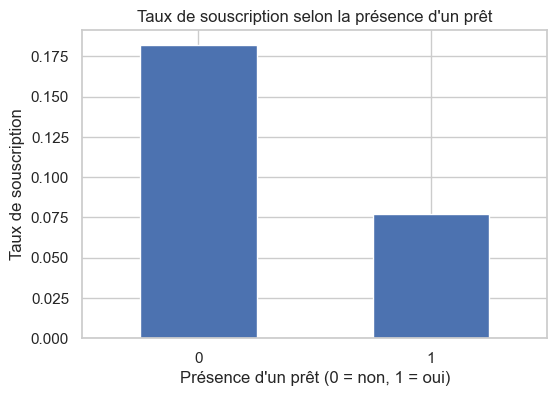

In [62]:
debt_subscription_rate = (
    eda_data.groupby("has_debt")["y"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

display(debt_subscription_rate)

debt_subscription_rate["yes"].plot(kind="bar", figsize=(6, 4))
plt.title("Taux de souscription selon la présence d'un prêt")
plt.xlabel("Présence d'un prêt (0 = non, 1 = oui)")
plt.ylabel("Taux de souscription")
plt.xticks(rotation=0)
plt.show()

### Synthèse EDA

Plusieurs signaux ressortent :

- un **résultat positif à la campagne précédente** est très fortement associé à une nouvelle souscription ;
- un **nombre élevé de contacts** au cours de la campagne ne semble pas être synonyme d'efficacité ;
- certaines professions apparaissent plus réceptives que d'autres ;
- l'endettement peut jouer un rôle, mais l'effet semble moins fort que l'historique marketing.

Ces constats sont utiles pour l'interprétation, mais ils doivent maintenant être consolidés par quelques tests statistiques.

## 12. Tests statistiques ciblés

Le cahier des charges demande d'aller au-delà des visualisations descriptives.  
On réalise donc deux tests simples :

1. **test du chi²** pour une relation entre deux variables catégorielles ;
2. **test de Mann-Whitney** pour comparer une variable numérique entre les deux classes.

Ces tests ne prouvent pas une causalité, mais ils permettent de vérifier si les écarts observés sont compatibles ou non avec l'hypothèse d'indépendance.

In [63]:
def chi2_test_table(df, feature, target="y"):
    table = pd.crosstab(df[feature], df[target])
    chi2, p_value, dof, _ = chi2_contingency(table)
    return pd.DataFrame({
        "feature": [feature],
        "chi2": [chi2],
        "p_value": [p_value],
        "degrees_of_freedom": [dof]
    })

chi2_results = pd.concat([
    chi2_test_table(data, "job"),
    chi2_test_table(data, "education"),
    chi2_test_table(data, "housing"),
    chi2_test_table(data, "poutcome")
], ignore_index=True)

display(chi2_results.sort_values("p_value"))

,feature,chi2,p_value,degrees_of_freedom
3,poutcome,"4,391.507",0.000,3
2,housing,874.822,0.000,1
0,job,836.105,0.000,11
1,education,238.924,0.000,3


In [64]:
group_no = data.loc[data["y"] == "no", "age"]
group_yes = data.loc[data["y"] == "yes", "age"]

stat, p_value = mannwhitneyu(group_no, group_yes, alternative="two-sided")

mw_result = pd.DataFrame({
    "variable": ["age"],
    "test": ["Mann-Whitney"],
    "statistic": [stat],
    "p_value": [p_value],
    "median_no": [group_no.median()],
    "median_yes": [group_yes.median()]
})

display(mw_result)

,variable,test,statistic,p_value,median_no,median_yes
0,age,Mann-Whitney,"107,232,348.500",0.063,39.000,38.000


### Interprétation des tests

Lorsque la **p-value** est très faible, on rejette l'hypothèse d'indépendance ou d'égalité de distribution.

Ici, cela signifie que certaines variables comme `poutcome` ou `job` ne semblent pas réparties au hasard par rapport à la cible.  
De même, si l'âge présente une différence statistiquement significative, cela confirme qu'il existe un écart global entre les groupes `yes` et `no`, même si cet écart peut rester modéré visuellement.

**Important :** avec un grand dataset, une différence peut être statistiquement significative sans être très forte en pratique.  
Il faut donc toujours croiser les tests avec l'interprétation métier.

## 13. Stratégie de modélisation

### Choix important : exclusion de `duration`

`duration` est souvent la variable la plus prédictive, car un appel long est fréquemment associé à une interaction plus engageante.  
Mais cette information n'est connue **qu'après** avoir appelé le client.

Or l'objectif métier est de décider **qui contacter avant l'appel**.  
Inclure `duration` donnerait donc un modèle artificiellement performant, mais inutilisable en ciblage réel.

On construit donc les modèles sur un jeu de variables **pré-appel**.

In [65]:
class BankFeatureCleaner(BaseEstimator, TransformerMixin):
    """Nettoyage métier :
    - remplace les 'unknown' par NaN ;
    - crée un indicateur pour pdays = -1 ;
    - remplace pdays = -1 par NaN.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
        for col in cat_cols:
            X[col] = X[col].replace("unknown", np.nan)

        if "pdays" in X.columns:
            X["pdays_was_never_contacted"] = (X["pdays"] == -1).astype(int)
            X["pdays"] = X["pdays"].replace(-1, np.nan)

        return X


class IQRClipper(BaseEstimator, TransformerMixin):
    """Clipping basé sur l'IQR pour limiter l'impact des valeurs extrêmes."""
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        self.columns_ = X_df.columns.tolist()
        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = q1 - self.factor * iqr
        self.upper_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.columns_).copy()
        return X_df.clip(lower=self.lower_, upper=self.upper_, axis=1)

    def get_feature_names_out(self, input_features=None):
        return np.array(input_features if input_features is not None else self.columns_)

In [66]:
model_data = data.copy()

# Exclusion de la cible et de duration (fuite d'information)
X = model_data.drop(columns=["y", "duration"])
y = model_data["y"].map({"no": 0, "yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# On nettoie d'abord un échantillon d'entraînement pour identifier les types de colonnes
X_train_clean = BankFeatureCleaner().fit_transform(X_train)
num_features = X_train_clean.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train_clean.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", IQRClipper(factor=1.5)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features)
])

print("Variables numériques :", num_features)
print("Variables catégorielles :", cat_features)

Variables numériques : ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'pdays_was_never_contacted']
Variables catégorielles : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### Pourquoi ce pipeline ?

Ce pipeline permet de rendre l'analyse **reproductible** et d'éviter les fuites entre entraînement et test.

- **imputation médiane** : robuste aux valeurs extrêmes ;
- **clipping IQR** : réduit l'effet des outliers ;
- **standardisation** : utile pour la régression logistique ;
- **one-hot encoding** : transforme les modalités textuelles en variables exploitables par les modèles.

## 14. Modèles comparés

On compare volontairement des approches différentes :

- **Régression logistique** : modèle simple, robuste et interprétable ;
- **Random Forest** : modèle non linéaire capable de capturer des interactions ;
- **XGBoost** : modèle de gradient boosting souvent performant sur des données tabulaires ;
- **Voting Classifier** : ensemble qui agrège plusieurs modèles.

Cette comparaison est importante pour répondre au cahier des charges et montrer qu'on ne dépend pas d'un seul algorithme.

In [67]:
models = {
    "Régression logistique": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )
}

if HAS_XGBOOST:
    models["XGBoost"] = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=4
    )

display(pd.DataFrame({"Modèles comparés": list(models.keys())}))

,Modèles comparés
0,Régression logistique
1,Random Forest


## 15. Validation croisée comparative

On utilise une **validation croisée stratifiée** pour obtenir une estimation plus fiable des performances qu'un simple score sur un seul découpage.

Pourquoi la validation croisée ?

- elle réduit la dépendance à un split unique ;
- elle donne une vision plus stable de la généralisation ;
- elle aide à comparer les modèles de manière plus juste.

In [68]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []

for model_name, model in models.items():
    pipe = Pipeline([
        ("cleaner", BankFeatureCleaner()),
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=["roc_auc", "f1", "precision", "recall", "accuracy"],
        n_jobs=1
    )

    cv_rows.append({
        "Modèle": model_name,
        "ROC_AUC_CV": scores["test_roc_auc"].mean(),
        "F1_CV": scores["test_f1"].mean(),
        "Precision_CV": scores["test_precision"].mean(),
        "Recall_CV": scores["test_recall"].mean(),
        "Accuracy_CV": scores["test_accuracy"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("ROC_AUC_CV", ascending=False).reset_index(drop=True)
display(cv_results)

,Modèle,ROC_AUC_CV,F1_CV,Precision_CV,Recall_CV,Accuracy_CV
0,Random Forest,0.758,0.391,0.296,0.575,0.791
1,Régression logistique,0.750,0.373,0.271,0.599,0.765


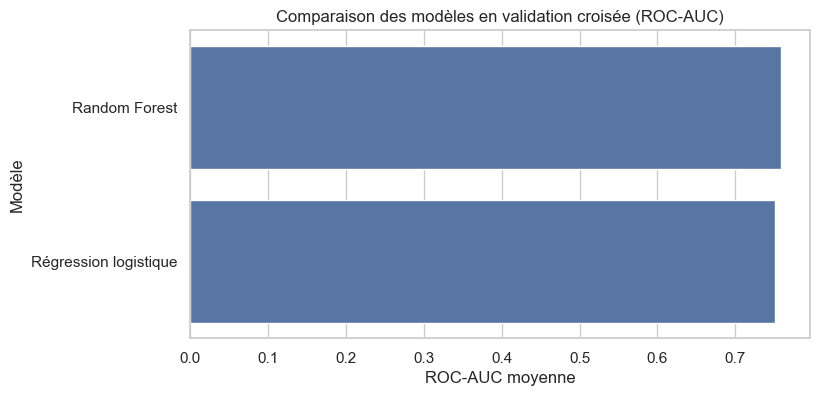

In [69]:
plt.figure(figsize=(8, 4))
sns.barplot(data=cv_results, x="ROC_AUC_CV", y="Modèle")
plt.title("Comparaison des modèles en validation croisée (ROC-AUC)")
plt.xlabel("ROC-AUC moyenne")
plt.ylabel("Modèle")
plt.show()

### Interprétation

Le classement par ROC-AUC donne une première hiérarchie des modèles.  
Mais il faut aussi regarder le compromis entre :

- **rappel** : ne pas manquer de clients potentiellement intéressés ;
- **précision** : éviter d'appeler trop de clients peu prometteurs.

Autrement dit, le “meilleur” modèle dépend partiellement de l'objectif métier.

## 16. Entraînement final du meilleur modèle

On retient ici le modèle ayant la meilleure **ROC-AUC moyenne en validation croisée**, puis on l'évalue proprement sur le jeu de test séparé au départ.

In [70]:
best_model_name = cv_results.loc[0, "Modèle"]
best_model = models[best_model_name]

final_pipeline = Pipeline([
    ("cleaner", BankFeatureCleaner()),
    ("preprocessor", preprocessor),
    ("model", best_model)
])

final_pipeline.fit(X_train, y_train)

y_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

test_metrics_default = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Value": [
        accuracy_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_default),
        roc_auc_score(y_test, y_proba)
    ]
})

print(f"Modèle retenu : {best_model_name}")
display(test_metrics_default)

Modèle retenu : Random Forest


,Metric,Value
0,Accuracy,0.790
1,Precision,0.299
2,Recall,0.589
3,F1-score,0.396
4,ROC-AUC,0.765


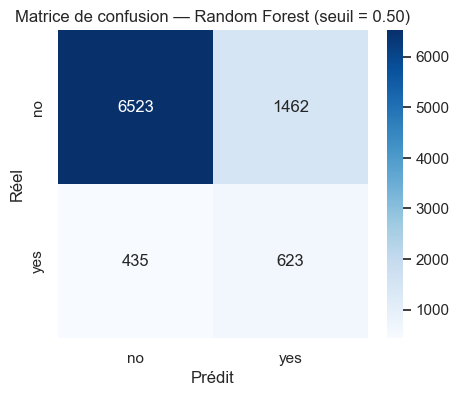

              precision    recall  f1-score   support

          no       0.94      0.82      0.87      7985
         yes       0.30      0.59      0.40      1058

    accuracy                           0.79      9043
   macro avg       0.62      0.70      0.63      9043
weighted avg       0.86      0.79      0.82      9043



In [71]:
cm_default = confusion_matrix(y_test, y_pred_default)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_default, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no", "yes"], yticklabels=["no", "yes"])
plt.title(f"Matrice de confusion — {best_model_name} (seuil = 0.50)")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

print(classification_report(y_test, y_pred_default, target_names=["no", "yes"]))

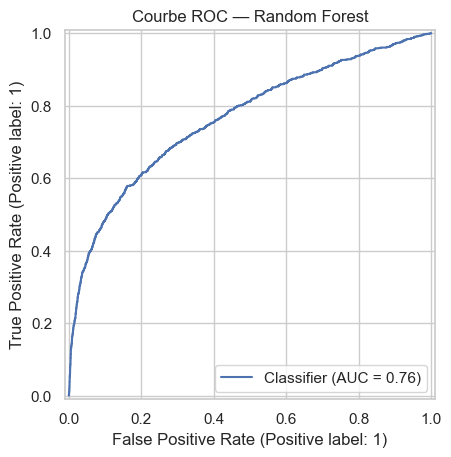

In [72]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f"Courbe ROC — {best_model_name}")
plt.show()

### Lecture des résultats au seuil standard

Le seuil de 0,50 est le réglage par défaut le plus courant, mais il n'est pas forcément optimal.

Dans un contexte marketing, on peut préférer :

- augmenter le **rappel** si l'on veut capter davantage de prospects potentiellement intéressés ;
- augmenter la **précision** si le coût d'appel est très important.

D'où l'intérêt d'étudier explicitement l'effet du seuil.

## 17. Ajustement du seuil de décision

Un modèle de classification renvoie des probabilités.  
Le passage en classe `yes` ou `no` dépend ensuite d'un **seuil de décision**.

Cette étape est essentielle car elle rapproche le modèle d'un **usage métier réel**.

In [73]:
thresholds = np.arange(0.10, 0.55, 0.05)

threshold_rows = []
for threshold in thresholds:
    pred_thr = (y_proba >= threshold).astype(int)
    threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "accuracy": accuracy_score(y_test, pred_thr),
        "precision": precision_score(y_test, pred_thr, zero_division=0),
        "recall": recall_score(y_test, pred_thr, zero_division=0),
        "f1": f1_score(y_test, pred_thr, zero_division=0),
        "predicted_yes_rate": pred_thr.mean()
    })

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)

,threshold,accuracy,precision,recall,f1,predicted_yes_rate
0,0.100,0.117,0.117,1.000,0.209,1.000
1,0.150,0.117,0.117,1.000,0.209,1.000
2,0.200,0.117,0.117,1.000,0.210,1.000
3,0.250,0.144,0.120,0.993,0.214,0.971
4,0.300,0.225,0.127,0.960,0.225,0.882
5,0.350,0.367,0.145,0.904,0.250,0.727
6,0.400,0.547,0.180,0.806,0.294,0.524
7,0.450,0.702,0.237,0.695,0.353,0.343
8,0.500,0.790,0.299,0.589,0.396,0.231


In [74]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)

f2_scores = (5 * precision[:-1] * recall[:-1]) / (4 * precision[:-1] + recall[:-1] + 1e-9)
best_idx = np.nanargmax(f2_scores)
best_threshold_f2 = float(pr_thresholds[best_idx])

y_pred_f2 = (y_proba >= best_threshold_f2).astype(int)

threshold_comparison = pd.DataFrame({
    "Scenario": ["Seuil standard 0.50", f"Seuil optimisé F2 ({best_threshold_f2:.2f})"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_default),
        accuracy_score(y_test, y_pred_f2)
    ],
    "Precision": [
        precision_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_f2)
    ],
    "Recall": [
        recall_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_f2)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_f2)
    ],
    "Prospects_ciblés_%": [
        y_pred_default.mean() * 100,
        y_pred_f2.mean() * 100
    ]
})

display(threshold_comparison)

,Scenario,Accuracy,Precision,Recall,F1-score,Prospects_ciblés_%
0,Seuil standard 0.50,0.790,0.299,0.589,0.396,23.057
1,Seuil optimisé F2 (0.46),0.725,0.250,0.675,0.364,31.627


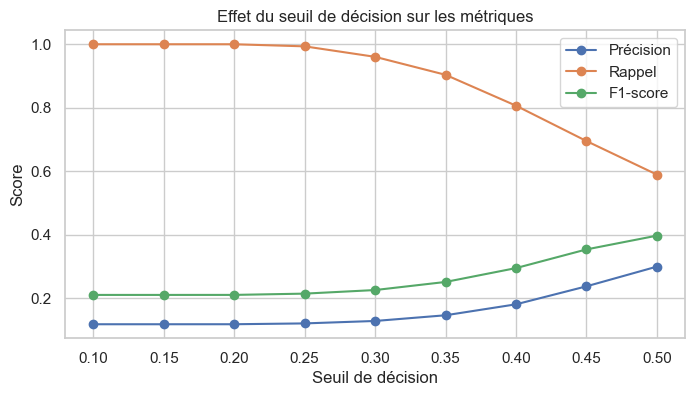

In [75]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_table["threshold"], threshold_table["precision"], marker="o", label="Précision")
plt.plot(threshold_table["threshold"], threshold_table["recall"], marker="o", label="Rappel")
plt.plot(threshold_table["threshold"], threshold_table["f1"], marker="o", label="F1-score")
plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Effet du seuil de décision sur les métriques")
plt.legend()
plt.show()

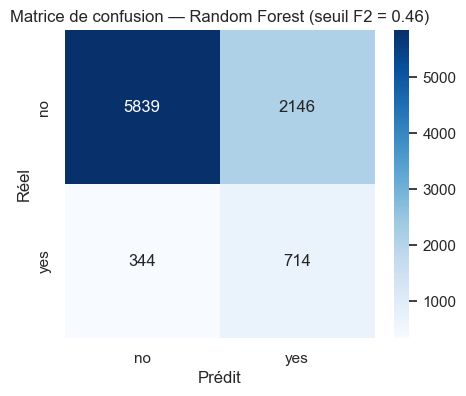

In [76]:
cm_f2 = confusion_matrix(y_test, y_pred_f2)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_f2, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no", "yes"], yticklabels=["no", "yes"])
plt.title(f"Matrice de confusion — {best_model_name} (seuil F2 = {best_threshold_f2:.2f})")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

### Interprétation métier

Abaisser le seuil augmente souvent le **rappel** mais diminue la **précision**.  
Concrètement :

- on détecte plus de clients susceptibles de souscrire ;
- mais on contacte aussi davantage de faux positifs.

Le bon seuil dépend donc du coût d'un appel et de la valeur commerciale d'une souscription.

## 18. Importance des variables du meilleur modèle

L'interprétation des variables importantes aide à relier la partie machine learning à la compréhension métier.

On extrait ici les variables transformées après le préprocessing pour visualiser celles qui pèsent le plus dans la décision du modèle.

In [77]:
preprocessor_fitted = final_pipeline.named_steps["preprocessor"]
feature_names = preprocessor_fitted.get_feature_names_out()

if best_model_name == "Régression logistique":
    importance_values = final_pipeline.named_steps["model"].coef_[0]
else:
    importance_values = final_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values,
    "abs_importance": np.abs(importance_values)
}).sort_values("abs_importance", ascending=False)

display(importance_df.head(15))

,feature,importance,abs_importance
37,cat__poutcome_success,0.291,0.291
22,cat__housing_yes,0.117,0.117
0,num__age,0.098,0.098
1,num__balance,0.079,0.079
32,cat__month_may,0.065,0.065
34,cat__month_oct,0.049,0.049
31,cat__month_mar,0.040,0.040
2,num__day,0.039,0.039
3,num__campaign,0.038,0.038
23,cat__loan_yes,0.023,0.023


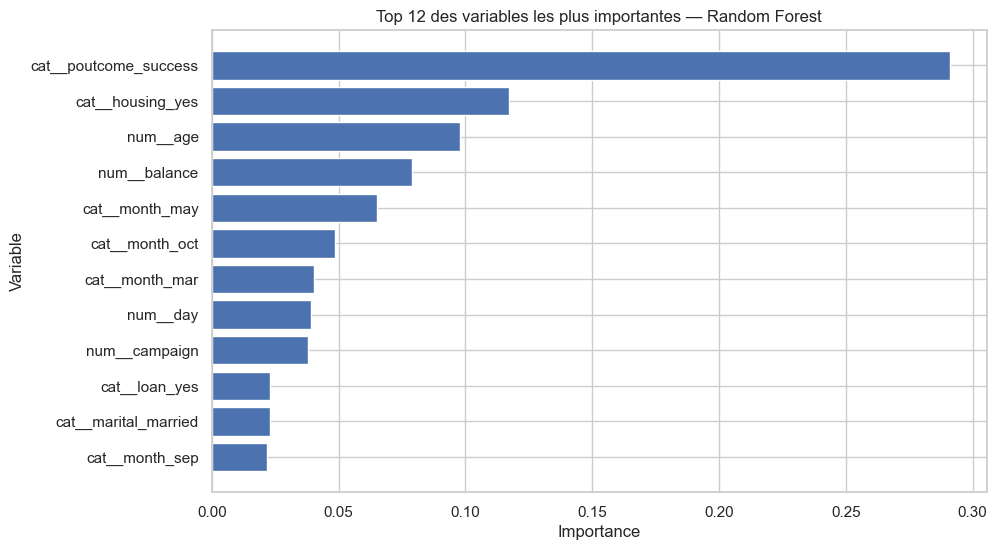

In [78]:
plot_df = importance_df.head(12).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title(f"Top 12 des variables les plus importantes — {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

### Interprétation

Les variables les plus importantes doivent être lues avec prudence :

- dans un modèle linéaire, le signe indique le sens de l'effet ;
- dans un modèle d'arbres, l'importance mesure surtout la contribution à la séparation des classes.

L'objectif n'est donc pas d'affirmer une causalité, mais d'identifier les variables les plus informatives pour la prédiction.

## 19. Voting Classifier — modèle d'ensemble

Pour aller plus loin, on construit un **modèle d'ensemble** qui combine plusieurs algorithmes.  
L'idée est simple : si plusieurs modèles captent des signaux complémentaires, leur combinaison peut améliorer la robustesse.

In [79]:
base_estimators = [
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
]

if HAS_XGBOOST:
    base_estimators.append(("xgb", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=4
    )))

voting_clf = VotingClassifier(
    estimators=base_estimators,
    voting="soft",
    n_jobs=-1
)

voting_pipeline = Pipeline([
    ("cleaner", BankFeatureCleaner()),
    ("preprocessor", preprocessor),
    ("model", voting_clf)
])

voting_pipeline.fit(X_train, y_train)
y_proba_voting = voting_pipeline.predict_proba(X_test)[:, 1]
y_pred_voting = (y_proba_voting >= 0.5).astype(int)

test_metrics_voting = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Voting_Classifier": [
        accuracy_score(y_test, y_pred_voting),
        precision_score(y_test, y_pred_voting),
        recall_score(y_test, y_pred_voting),
        f1_score(y_test, y_pred_voting),
        roc_auc_score(y_test, y_proba_voting)
    ]
})

display(test_metrics_voting)

KeyboardInterrupt: 

In [ ]:
comparison_test = test_metrics_default.merge(test_metrics_voting, on="Metric", how="left")
comparison_test = comparison_test.rename(columns={"Value": best_model_name})
display(comparison_test)

,Metric,Random Forest,Voting_Classifier
0,Accuracy,0.790,0.782
1,Precision,0.299,0.291
2,Recall,0.589,0.600
3,F1-score,0.396,0.392
4,ROC-AUC,0.765,0.764


### Lecture comparative

Le Voting Classifier n'est pas automatiquement meilleur.  
Son intérêt est surtout de vérifier si la combinaison de modèles apporte un gain de robustesse ou de performance.

S'il ne surpasse pas clairement le meilleur modèle simple, on peut préférer conserver un modèle plus facile à expliquer.

## 20. Limites de l'analyse

Aucune modélisation n'est parfaite. Les principales limites ici sont les suivantes :

1. **Déséquilibre de la cible** : la classe positive reste minoritaire.
2. **Variable `duration` exclue** : cela réduit le score brut, mais rend le modèle réaliste.
3. **Modalités `unknown`** : leur signification exacte reste ambiguë.
4. **Absence d'informations externes** : le dataset ne contient pas, par exemple, la valeur vie client ou le coût exact d'un appel.
5. **Temporalité limitée** : certains comportements peuvent évoluer d'une campagne à l'autre.

Ces limites doivent être dites clairement en soutenance, car elles montrent une compréhension critique du projet.

## 21. Conclusion générale

Cette analyse permet de répondre aux trois objectifs du projet :

- **comprendre** quels profils souscrivent davantage ;
- **identifier** les facteurs les plus associés à la décision ;
- **prédire** les clients à cibler avec un modèle reproductible.

### Conclusion synthétique

- l'historique marketing, en particulier `poutcome`, joue un rôle central ;
- certaines variables de profil et de contexte de contact apportent également de l'information ;
- la régression logistique offre une base solide et interprétable ;
- les modèles non linéaires permettent de tester des relations plus complexes ;
- l'ajustement du seuil est indispensable pour adapter le modèle à un objectif métier.

En résumé, le projet montre qu'un ciblage plus intelligent est possible, à condition de rester vigilant sur l'interprétation, la fuite d'information et le compromis entre précision et rappel.